creating chart for volumetric and 2D represntation


Processing: B-cell_infiltration
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_B-cell_infiltration.png


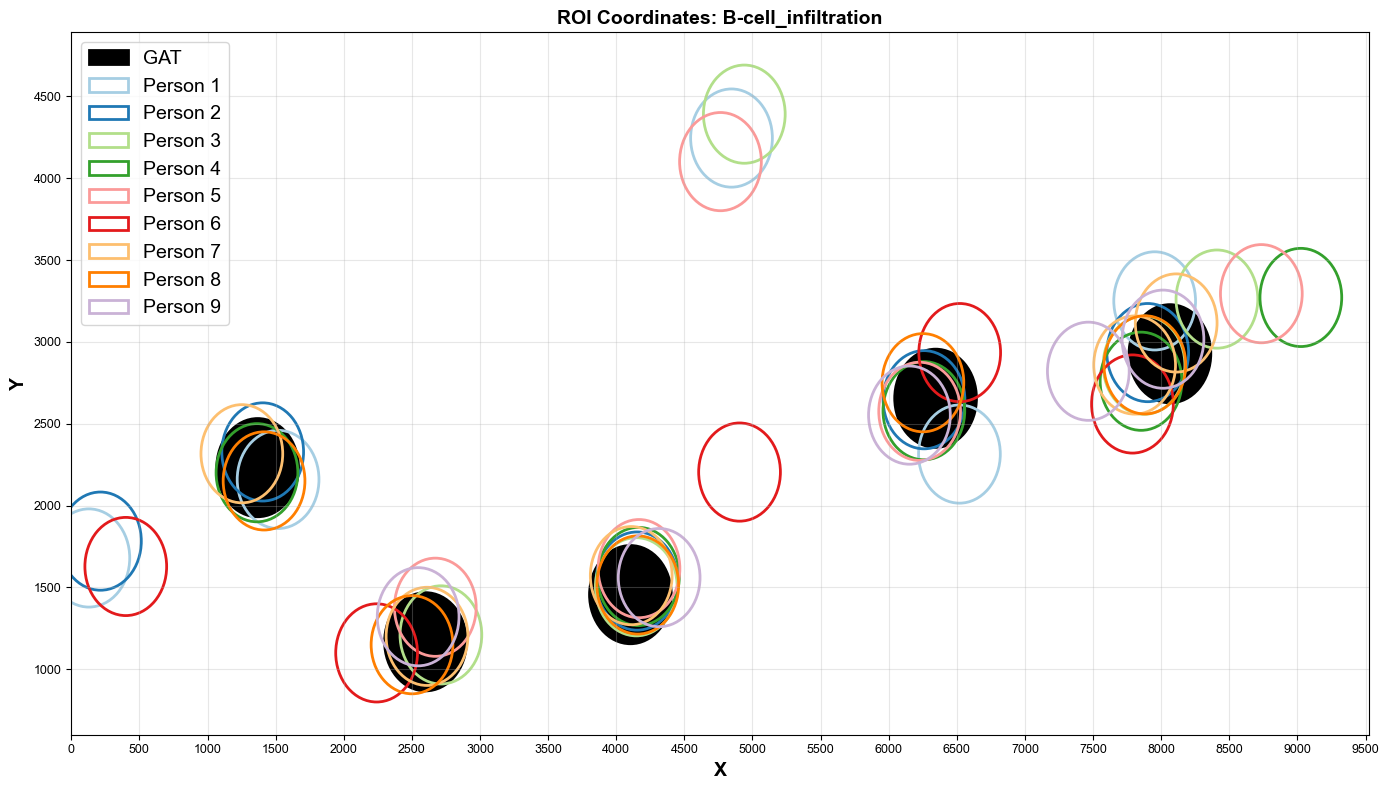


Processing: Inflammatory_zone
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Inflammatory_zone.png


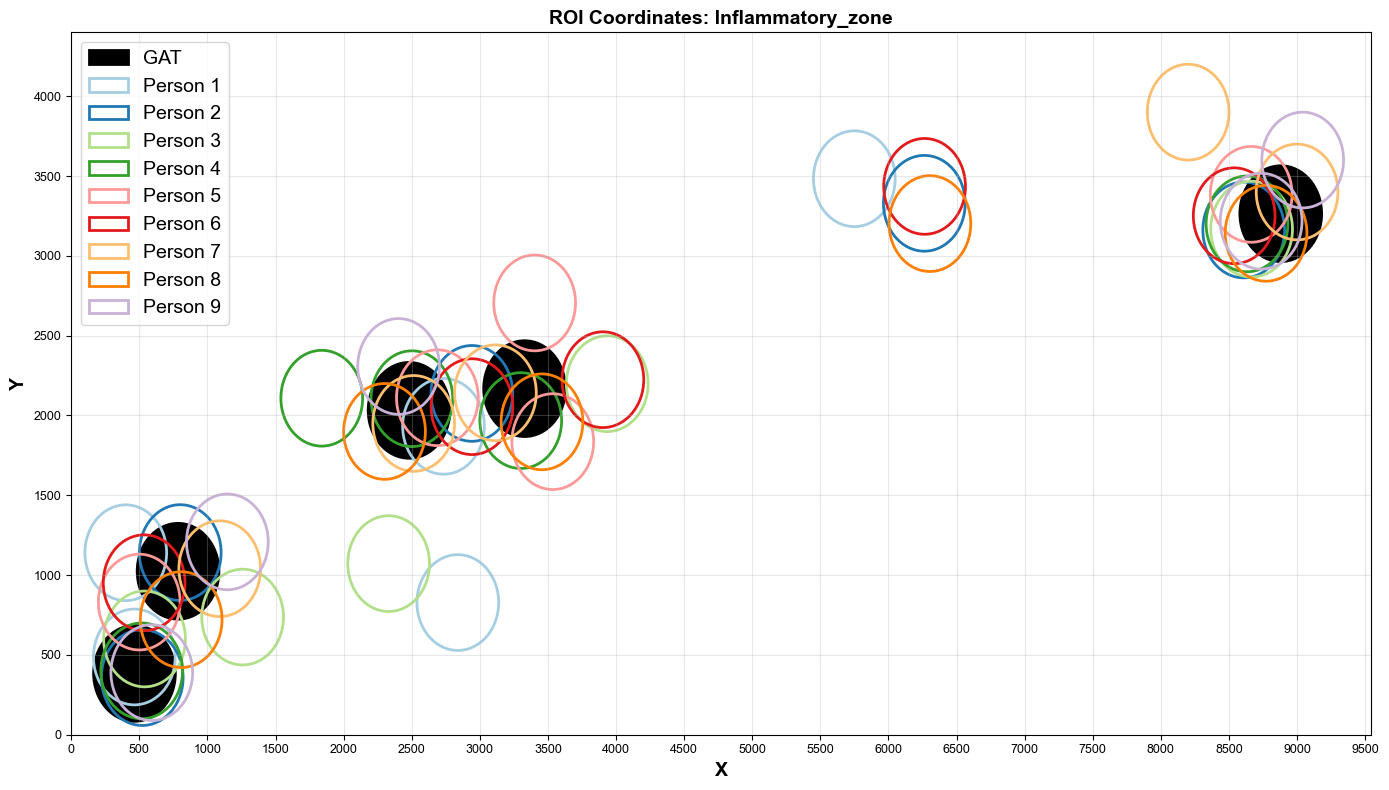


Processing: Oxidative_stress_regulation
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_Oxidative_stress_regulation.png


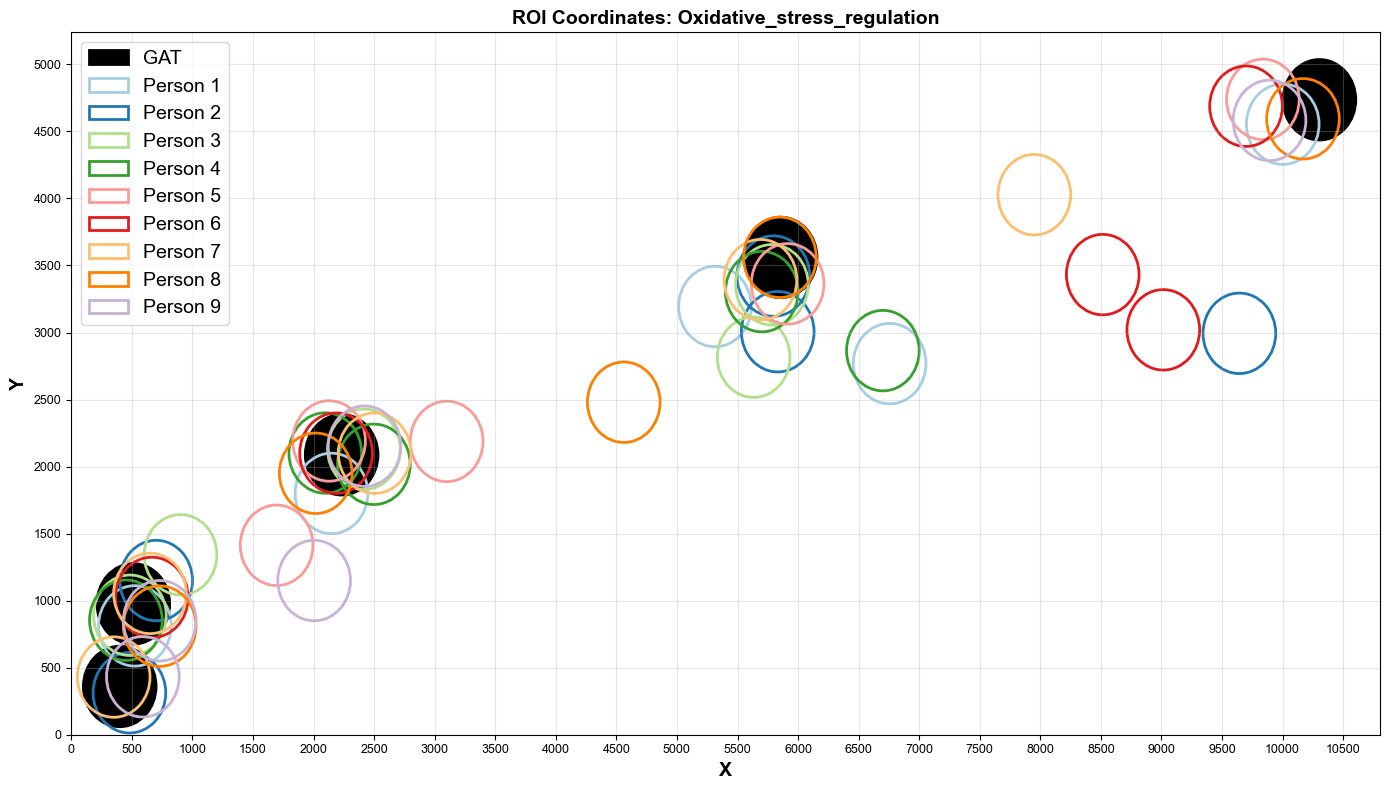


Processing: T-cell_maturation
  Total rows: 50
  GAT rows: 5
  Unique identifiers: ['GAT' 'Person 1' 'Person 2' 'Person 3' 'Person 4' 'Person 5' 'Person 6'
 'Person 7' 'Person 8' 'Person 9']
  ✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\roi_plot_T-cell_maturation.png


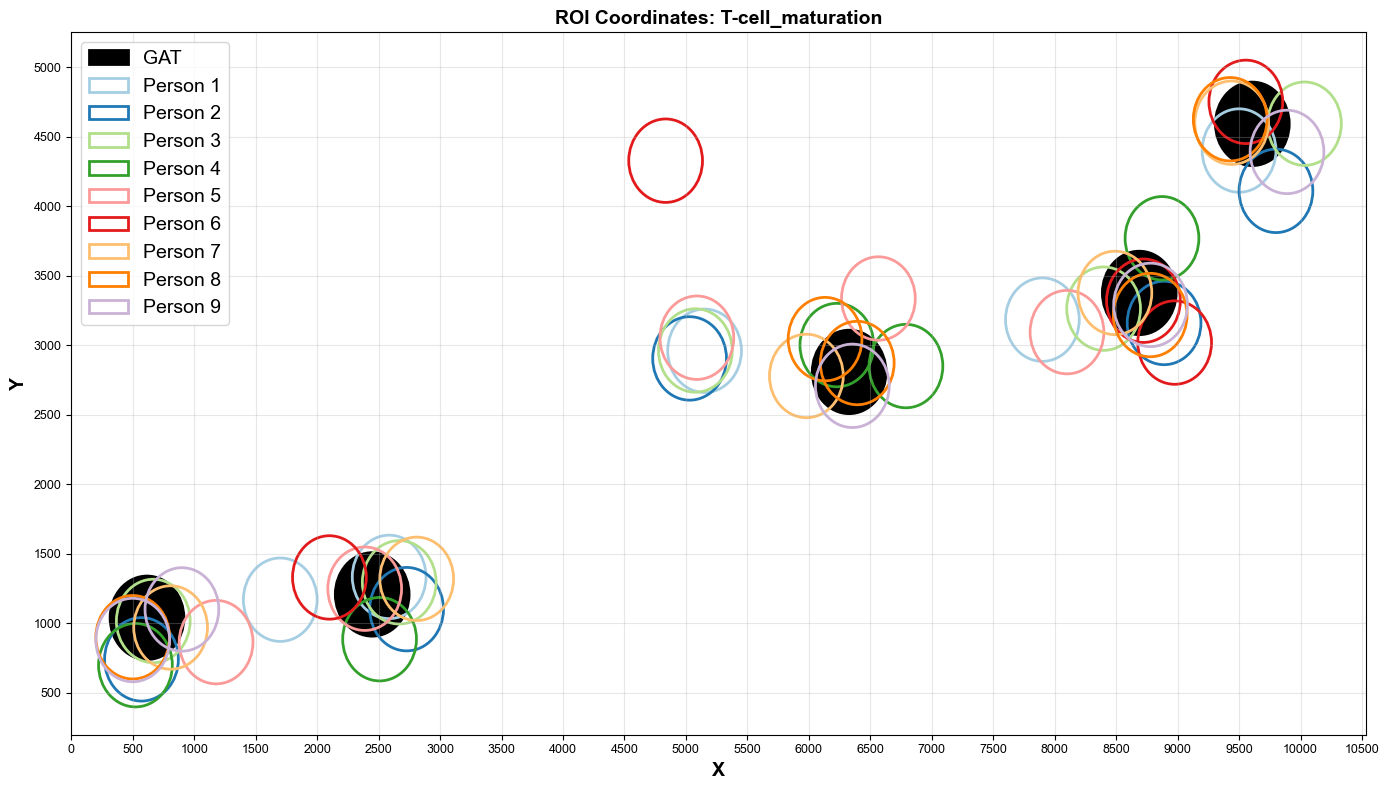


✓ All 2D plots created successfully!

Creating 3D Scatter Plots for each region/topic...

Processing 3D plot: B-cell_infiltration

Processing 3D plot: Inflammatory_zone

Processing 3D plot: Oxidative_stress_regulation

Processing 3D plot: T-cell_maturation

✓ All 3D scatter plots created successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import numpy as np

# Define file paths
base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

# Color palette
colors = {
    'GAT': '#000000',           # Black (filled)
    'Person 1': '#a6cee3',      # Light blue
    'Person 2': '#1f78b4',       # Blue
    'Person 3': '#b2df8a',       # Light green
    'Person 4': '#33a02c',       # Green
    'Person 5': '#fb9a99',       # Light red
    'Person 6': '#e31a1c',       # Red
    'Person 7': '#fdbf6f',       # Light orange
    'Person 8': '#ff7f00',       # Orange
    'Person 9': '#cab2d6'        # Light purple
}

# Markers for 3D scatter plot
markers_3d = {
    'GAT': 'o',           # Circle
    'Person 1': 's',      # Square
    'Person 2': '^',      # Triangle up
    'Person 3': 'D',      # Diamond
    'Person 4': 'v',      # Triangle down
    'Person 5': 'p',      # Pentagon
    'Person 6': 'X',      # X
    'Person 7': '*',      # Star
    'Person 8': 'h',      # Hexagon
    'Person 9': '+'       # Plus
}

# Circle parameters (must match cylinder_radius in Cell 2 for consistency)
circle_radius = 300
stroke_width = 2

# Process each CSV file
for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file (CSV format: Model, ROI_ID, x, y, z)
    # header=0 means first row is header (Model, ROI_ID, x, y, z)
    df = pd.read_csv(csv_path, header=0)
    
    # Extract sheet name from filename
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    print(f"\nProcessing: {sheet_name}")
    print(f"  Total rows: {len(df)}")
    print(f"  GAT rows: {len(df[df.iloc[:, 0] == 'GAT'])}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Collect all valid x, y coordinates for dynamic axis limits
    all_x_coords = []
    all_y_coords = []
    
    # Group data by identifier (first column) and plot
    identifiers = df.iloc[:, 0].unique()  # Get unique identifiers from first column
    print(f"  Unique identifiers: {identifiers}")
    
    for identifier in identifiers:
        # Get all rows for this identifier
        identifier_data = df[df.iloc[:, 0] == identifier]
        
        # Get color for this identifier
        if identifier in colors:
            color = colors[identifier]
        else:
            # Default color if not in palette
            color = '#808080'
            print(f"  Warning: No color defined for '{identifier}', using gray")
        
        # Determine if filled (GAT) or hollow (others)
        is_filled = (identifier == 'GAT')
        
        # Plot circles for each row
        for idx, row in identifier_data.iterrows():
            # Access columns by name: CSV format is Model, ROI_ID, x, y, z
            x_val = row['x']  # x coordinate
            y_val = row['y']  # y coordinate
            
            # Check if valid
            if pd.notna(x_val) and pd.notna(y_val):
                try:
                    x_float = float(x_val)
                    y_float = float(y_val)
                    
                    if not (np.isnan(x_float) or np.isnan(y_float)):
                        # Collect coordinates for dynamic axis limits
                        all_x_coords.append(x_float)
                        all_y_coords.append(y_float)
                        
                        # Create circle (2D projection of 3D cylinder used in Cell 2)
                        if is_filled:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=True, facecolor=color,
                                          edgecolor=color, linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        else:
                            circle = Circle((x_float, y_float), circle_radius,
                                          fill=False, edgecolor=color,
                                          linewidth=stroke_width,
                                          label=identifier if idx == identifier_data.index[0] else '')
                        ax.add_patch(circle)
                except (ValueError, TypeError):
                    continue
    
    # Set axis limits dynamically based on data (with padding for circles)
    if len(all_x_coords) > 0 and len(all_y_coords) > 0:
        x_min, x_max = min(all_x_coords), max(all_x_coords)
        y_min, y_max = min(all_y_coords), max(all_y_coords)
        # Add padding (circle radius + margin)
        padding = circle_radius + 200
        ax.set_xlim(max(0, x_min - padding), x_max + padding)
        ax.set_ylim(max(0, y_min - padding), y_max + padding)
    else:
        # Fallback to default limits if no valid coordinates
        ax.set_xlim(0, 11000)
        ax.set_ylim(0, 6000)
    # Set tick step to 100
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.yaxis.set_major_locator(MultipleLocator(500))
    # Set labels and title
    ax.set_xlabel('X', fontsize=14,fontweight='bold')
    ax.set_ylabel('Y', fontsize=14,fontweight='bold')
    ax.set_title(f'ROI Coordinates: {sheet_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=14)
    
    # Save plot
    plt.tight_layout()
    output_path = base_dir / f'roi_plot_{sheet_name}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.show()

print(f"\n✓ All 2D plots created successfully!")

# Now create 3D scatter plots for each topic
print(f"\n{'='*70}")
print("Creating 3D Scatter Plots for each region/topic...")
print(f"{'='*70}")

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"Warning: CSV file not found: {csv_path}")
        continue
    
    # Read CSV file
    df = pd.read_csv(csv_path)
    
    # Extract sheet name from filename
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    print(f"\nProcessing 3D plot: {sheet_name}")
    

print(f"\n✓ All 3D scatter plots created successfully!")


Processing volumetric data...
  ✓ Person 1 in B-cell_infiltration: 5 overlaps, mean=32.49%
  ✓ Person 2 in B-cell_infiltration: 5 overlaps, mean=58.10%
  ✓ Person 3 in B-cell_infiltration: 5 overlaps, mean=31.53%
  ✓ Person 4 in B-cell_infiltration: 5 overlaps, mean=19.00%
  ✓ Person 5 in B-cell_infiltration: 5 overlaps, mean=43.11%
  ✓ Person 6 in B-cell_infiltration: 5 overlaps, mean=25.36%
  ✓ Person 7 in B-cell_infiltration: 5 overlaps, mean=64.56%
  ✓ Person 8 in B-cell_infiltration: 5 overlaps, mean=80.90%
  ✓ Person 9 in B-cell_infiltration: 5 overlaps, mean=36.87%
  ✓ Person 1 in Inflammatory_zone: 5 overlaps, mean=36.03%
  ✓ Person 2 in Inflammatory_zone: 5 overlaps, mean=40.14%
  ✓ Person 3 in Inflammatory_zone: 5 overlaps, mean=20.21%
  ✓ Person 4 in Inflammatory_zone: 5 overlaps, mean=41.38%
  ✓ Person 5 in Inflammatory_zone: 5 overlaps, mean=22.63%
  ✓ Person 6 in Inflammatory_zone: 5 overlaps, mean=17.00%
  ✓ Person 7 in Inflammatory_zone: 5 overlaps, mean=12.25%
  ✓ Pers

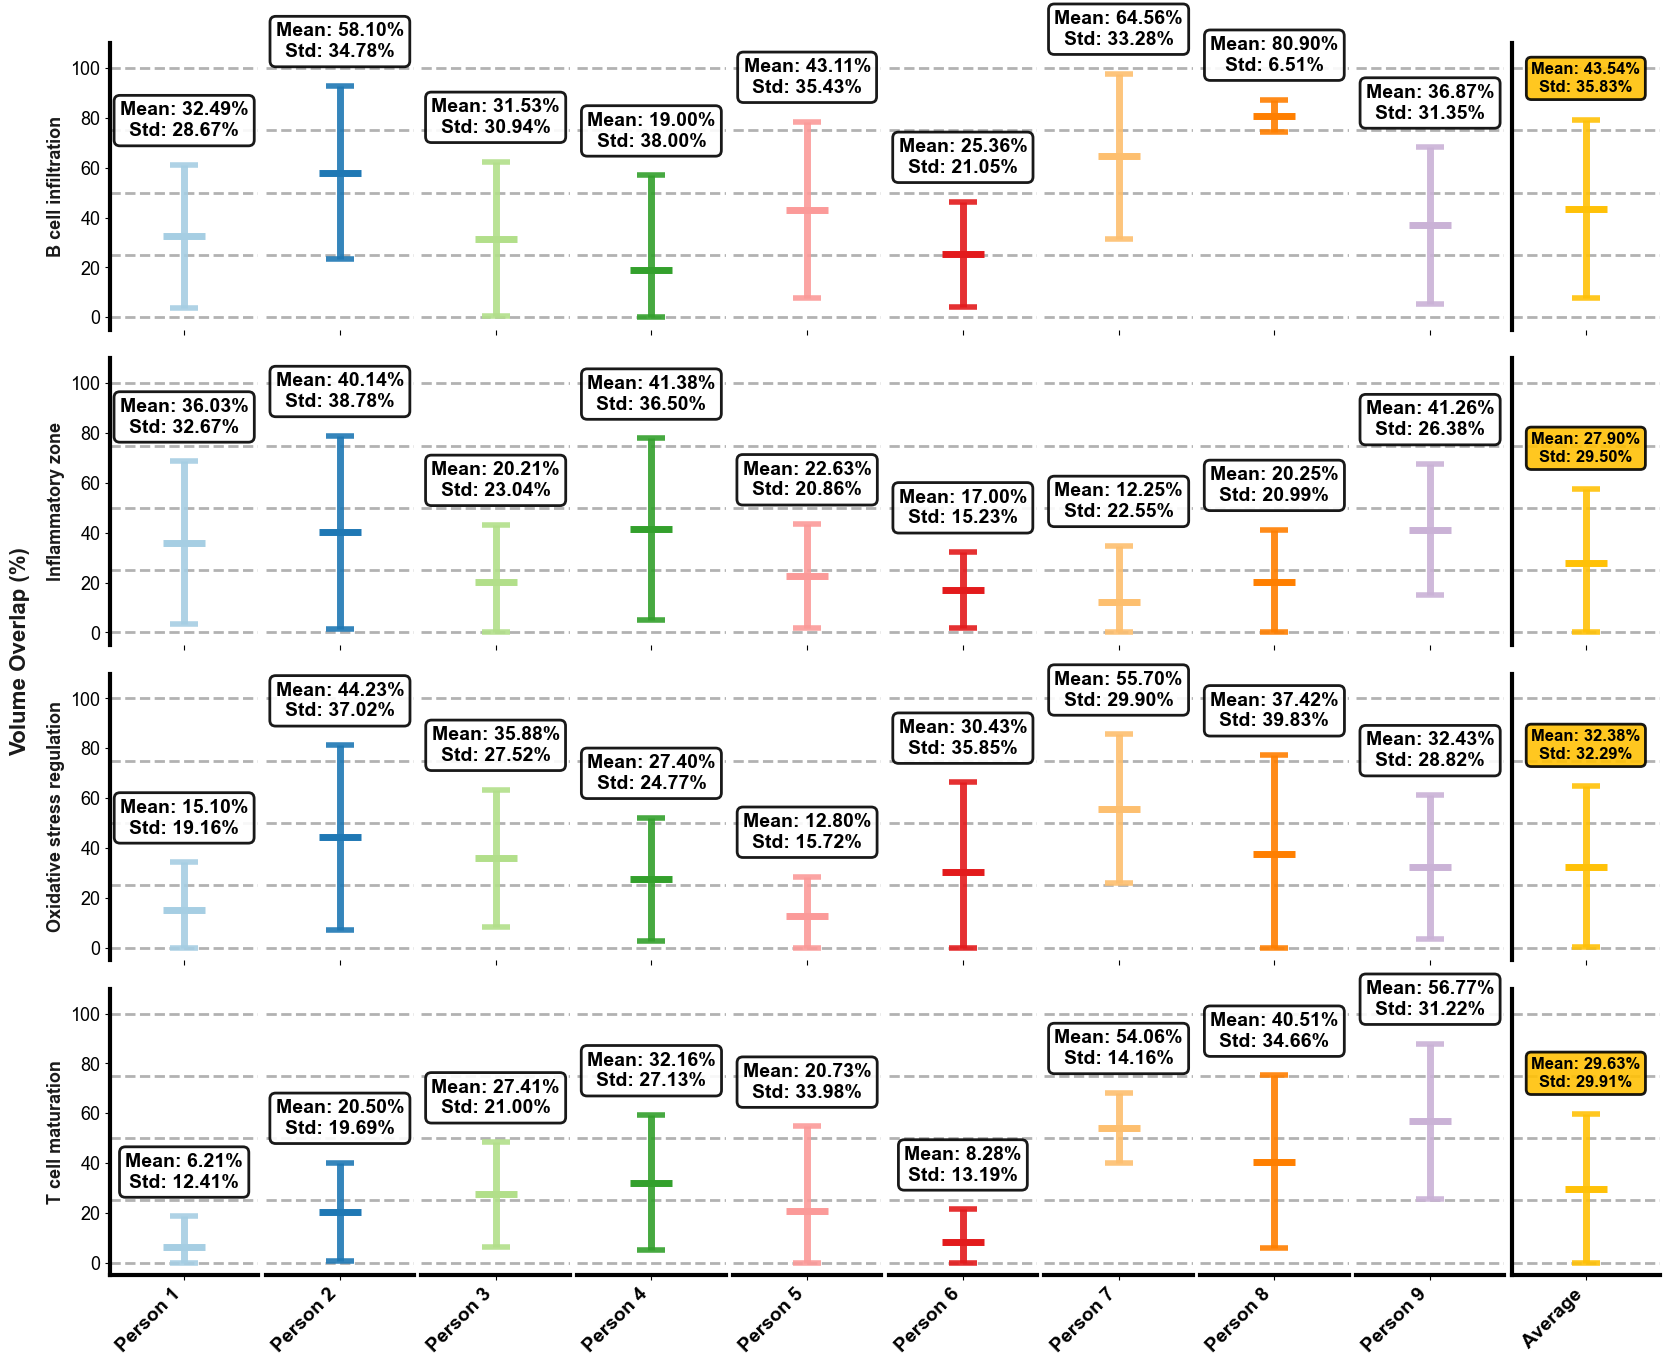

In [6]:
"""
Inter-Rater Error Bar Chart for Volumetric Data
Creates error bar chart similar to Euclidean distance chart
Grid: 4 rows (topics/microenvironments) x 10 columns (9 Persons + Average)
Each cell shows vertical error bar with Mean ± Std
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math
import warnings
import os
warnings.filterwarnings('ignore')

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth'
base_dir = Path(BASE_DIR)
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

cylinder_radius, cylinder_height = 400, 50
z_tolerance = 50

def circle_overlap(c1, c2, r):
    d = math.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)
    if d >= 2*r: return 0.0
    if d == 0: return 100.0
    try:
        area = 2*r**2*math.acos(d/(2*r)) - (d/2)*math.sqrt(4*r**2-d**2)
        return min(100.0, (area/(math.pi*r**2))*100)
    except: return 100.0 if d < 2*r else 0.0

def z_overlap(z1, z2, h, z_tol):
    dz = abs(z1 - z2)
    if dz <= z_tol:
        return 100.0
    excess_diff = dz - z_tol
    overlap_percent = max(0.0, 100.0 - (excess_diff / h) * 100)
    return overlap_percent

def volume_overlap(c1, z1, c2, z2, r, h, z_tol):
    xy_overlap = circle_overlap(c1, c2, r) / 100.0
    z_overlap_pct = z_overlap(z1, z2, h, z_tol) / 100.0
    return min(100.0, xy_overlap * z_overlap_pct * 100.0)

def calc_overlaps(gat_data, person_data, r, h, z_tol):
    if len(gat_data) == 0 or len(person_data) == 0: return []
    
    # Clean data: remove rows with NaN values and ensure numeric types
    gat_clean = gat_data[['x', 'y', 'z']].copy()
    person_clean = person_data[['x', 'y', 'z']].copy()
    
    # Convert to numeric, coercing errors to NaN
    for col in ['x', 'y', 'z']:
        gat_clean[col] = pd.to_numeric(gat_clean[col], errors='coerce')
        person_clean[col] = pd.to_numeric(person_clean[col], errors='coerce')
    
    # Drop rows with any NaN values
    gat_clean = gat_clean.dropna()
    person_clean = person_clean.dropna()
    
    if len(gat_clean) == 0 or len(person_clean) == 0: 
        return []
    
    gat = gat_clean.values
    person = person_clean.values
    
    # Ensure we have valid numeric arrays
    if not (np.isfinite(gat).all() and np.isfinite(person).all()):
        return []
    
    rows, cols = linear_sum_assignment(cdist(gat, person))
    return [volume_overlap((gat[i][0], gat[i][1]), gat[i][2], (person[j][0], person[j][1]), person[j][2], r, h, z_tol)
            for i, j in zip(rows, cols)]

# Process each CSV file - always process to ensure Person 7, 8, 9 are included
print("Processing volumetric data...")
results = {}
all_overlaps = {f'Person {i}': [] for i in range(1, 10)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    # Filter GAT data - ensure we get exact match (case-sensitive)
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    
    # Clean GAT data: remove rows with NaN in coordinates
    gat_data = gat_data.dropna(subset=['x', 'y', 'z'])
    # Convert to numeric
    for col in ['x', 'y', 'z']:
        gat_data[col] = pd.to_numeric(gat_data[col], errors='coerce')
    gat_data = gat_data.dropna(subset=['x', 'y', 'z'])
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    if len(gat_data) == 0:
        print(f"  Warning: No valid GAT data found in {sheet_name}")
        continue
    
    results[sheet_name] = {}
    
    for person_num in range(1, 10):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        
        # Clean person data: remove rows with NaN in coordinates
        person_data = person_data.dropna(subset=['x', 'y', 'z'])
        # Convert to numeric
        for col in ['x', 'y', 'z']:
            person_data[col] = pd.to_numeric(person_data[col], errors='coerce')
        person_data = person_data.dropna(subset=['x', 'y', 'z'])
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            print(f"  Warning: No valid data found for {person_name} in {sheet_name}")
            continue
        
        overlaps = calc_overlaps(gat_data, person_data, cylinder_radius, cylinder_height, z_tolerance)
        
        if len(overlaps) > 0:
            results[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': np.mean(overlaps),
                'median': np.median(overlaps),
                'std': np.std(overlaps),
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps[person_name].extend(overlaps)
            print(f"  ✓ {person_name} in {sheet_name}: {len(overlaps)} overlaps, mean={np.mean(overlaps):.2f}%")
        else:
            print(f"  Warning: No overlaps calculated for {person_name} in {sheet_name}")

print("✓ Data processing complete.")

# Get topics and person names
person_names = [f'Person {i}' for i in range(1, 10)]
person_colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6']
topics_list = list(results.keys()) if len(results) > 0 else []

# Set better font settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

if len(topics_list) > 0:
    # Grid: rows = topics (microenvironments), columns = persons + average
    num_topics = len(topics_list)
    num_cols = len(person_names) + 1  # +1 for average column
    fig = plt.figure(figsize=(20, 4 * num_topics))
    gs = fig.add_gridspec(num_topics, num_cols, hspace=0.1, wspace=0.05)

    for row_idx, sheet_name in enumerate(topics_list):
        all_topic_overlaps = []
        
        # Plot each person in columns
        for col_idx, person_name in enumerate(person_names):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            if person_name in results[sheet_name]:
                overlaps = results[sheet_name][person_name]['overlaps']
                if len(overlaps) > 0:
                    all_topic_overlaps.extend(overlaps)
                    stats = results[sheet_name][person_name]
                    # Use mean for error bar plot
                    mean_val = stats['mean']
                    std_val = stats['std']
                    
                    # Create error bar plot (vertical, similar to Euclidean plot)
                    x_pos = 0.5
                    color = person_colors[col_idx]
                    
                    # Error bar (vertical line with caps) - thicker lines
                    # Limit error bar to minimum 0 (mean - std cannot be negative)
                    # Also limit upper error bar to maximum 100% (volume overlap cannot exceed 100%)
                    yerr_lower = min(std_val, mean_val)  # Ensure error bar doesn't go below 0
                    yerr_upper = min(std_val, 100 - mean_val)  # Ensure error bar doesn't go above 100%
                    ax.errorbar(x_pos, mean_val, yerr=[[yerr_lower], [yerr_upper]], fmt='none', color=color, 
                               capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
                    # Point estimate (horizontal line marker) - thicker
                    ax.plot(x_pos, mean_val, marker='_', color=color, markersize=30, 
                           markeredgewidth=5, alpha=1.0, linewidth=6)
                    
                    stats_text = f"Mean: {mean_val:.2f}%\nStd: {std_val:.2f}%"
                    # Position text 10 units above the maximum error bar (but not more than 110)
                    text_y_pos = min(mean_val + yerr_upper + 10, 110)
                    ax.text(x_pos, text_y_pos, stats_text,
                           ha='center', va='bottom', fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
                else:
                    # Empty plot
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=14, color='gray')
            else:
                # Empty plot
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                       ha='center', va='center', fontsize=14, color='gray')
            
            # Set ylim to accommodate text boxes - limit to 110% max (since values cannot exceed 100%)
            ax.set_ylim(-5, 110)
            ax.set_xlim(0, 1)
            ax.set_xticks([0.5])
            ax.set_xticklabels([person_name], rotation=45, ha='right', fontsize=14, fontweight='bold')
            
            # For first column, only show specific dash lines (0, 25, 50, 75, 100)
            # For other columns, show grid
            if col_idx == 0:
                # Add horizontal dash lines at 0, 25, 50, 75, 100 only
                for y_val in [0, 25, 50, 75, 100]:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            else:
                ax.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
                # Add horizontal dash lines at 0, 25, 50, 75, 100
                for y_val in [0, 25, 50, 75, 100]:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            
            ax.tick_params(axis='x', labelsize=14, colors='black')
            ax.tick_params(axis='y', labelsize=13, colors='black')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(3)
            ax.spines['bottom'].set_linewidth(3)
            if row_idx < num_topics - 1:
                ax.spines['bottom'].set_visible(False)
            if col_idx > 0:
                ax.spines['left'].set_visible(False)
            
            if col_idx == 0:
                # Set microenvironment name as ylabel
                microenv_name = sheet_name.replace('_', ' ').replace('-', ' ')
                ax.set_ylabel(microenv_name, fontsize=13, fontweight='bold', color='#1a1a1a')
            else:
                ax.set_ylabel('')
                ax.set_yticks([])
            
            if row_idx < num_topics - 1:
                ax.set_xticklabels([])
        
        # Plot average in last column (using mean)
        ax_avg = fig.add_subplot(gs[row_idx, num_cols - 1])
        if len(all_topic_overlaps) > 0:
            mean_avg = np.mean(all_topic_overlaps)
            std_avg = np.std(all_topic_overlaps)
            x_pos_avg = 0.5
            
            # Error bar for average (vertical) - thicker lines
            # Limit error bar to minimum 0 (mean - std cannot be negative)
            # Also limit upper error bar to maximum 100% (volume overlap cannot exceed 100%)
            yerr_lower_avg = min(std_avg, mean_avg)  # Ensure error bar doesn't go below 0
            yerr_upper_avg = min(std_avg, 100 - mean_avg)  # Ensure error bar doesn't go above 100%
            ax_avg.errorbar(x_pos_avg, mean_avg, yerr=[[yerr_lower_avg], [yerr_upper_avg]], fmt='none', color='#FFC107', 
                           capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
            ax_avg.plot(x_pos_avg, mean_avg, marker='_', color='#FFC107', markersize=30, 
                       markeredgewidth=5, alpha=1.0, linewidth=6)
            
            stats_text = f"Mean: {mean_avg:.2f}%\nStd: {std_avg:.2f}%"
            # Position text 10 units above the maximum error bar (but not more than 110)
            text_y_pos_avg = min(mean_avg + yerr_upper_avg + 10, 110)
            ax_avg.text(x_pos_avg, text_y_pos_avg, stats_text,
                       ha='center', va='bottom', fontsize=12, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='#FFC107', alpha=0.9, edgecolor='black', linewidth=2))
        else:
            ax_avg.text(0.5, 0.5, 'No data', transform=ax_avg.transAxes,
                       ha='center', va='center', fontsize=12, color='gray')
        
        # Set ylim to accommodate text boxes - limit to 110% max (since values cannot exceed 100%)
        ax_avg.set_ylim(-5, 110)
        ax_avg.set_xlim(0, 1)
        ax_avg.set_xticks([0.5])
        ax_avg.set_xticklabels(['Average'], rotation=45, ha='right', fontsize=12, fontweight='bold')
        ax_avg.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
        
        # Add horizontal dash lines at 0, 25, 50, 75, 100
        for y_val in [0, 25, 50, 75, 100]:
            ax_avg.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
        
        ax_avg.tick_params(axis='x', labelsize=14, colors='black')
        ax_avg.tick_params(axis='y', labelsize=13, colors='black')
        if row_idx < num_topics - 1:
            ax_avg.set_xticklabels([])
        ax_avg.spines['top'].set_visible(False)
        ax_avg.spines['right'].set_visible(False)
        ax_avg.spines['left'].set_linewidth(3)
        ax_avg.spines['bottom'].set_linewidth(3)
        if row_idx < num_topics - 1:
            ax_avg.spines['bottom'].set_visible(False)
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])
    
    # Add "Volume Overlap (%)" label on the leftmost position for all rows
    fig.text(0.08, 0.5, 'Volume Overlap (%)', fontsize=16, fontweight='bold', 
             rotation=90, va='center', ha='center', color='#1a1a1a')

    # fig.suptitle('Volume Overlap by Microenvironment (Rows) and Person (Columns)-(Error bars show Mean ± Std)', 
                #  fontsize=20, fontweight='bold', y=0.95, color='#1a1a1a')
    plt.tight_layout(rect=[0.04, 0.02, 1, 0.97])
    output_path = base_dir / 'errorbar_grid_all_topics_volumetric.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()

